# NeuroQWERTY - test final DWT/DTW + XGBoost

Objectif : vérifier proprement si une représentation plus proche de l’état de l’art récent peut battre le modèle applicatif actuel `agg_timing_xgb`.

Le protocole reste strict :

- séparation groupée par sujet (`pID`) ;
- objectif principal `ROC-AUC`, plus adapté à la fusion tardive ;
- répétition des splits pour mesurer la stabilité ;
- comparaison directe contre la baseline applicative actuelle ;
- export uniquement si la méthode DWT/DTW est meilleure et suffisamment stable.

Le DTW est calculé vers des prototypes construits uniquement sur les sujets d’entraînement de chaque fold. Les sujets de validation/test ne participent donc jamais à la construction de ces prototypes.


## 0. Configuration


In [1]:
from pathlib import Path
import re
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import pywt
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
REPEAT_SEEDS = [42, 1337, 2026]
OUTER_SPLITS = 5
INNER_SPLITS = 5
WINDOW = 300
STRIDE = 150
MIN_LEN = 300
SIGNAL_LEN = 300
DTW_LEN = 64
WAVELET = "db4"
WAVELET_LEVEL = 4
PRIMARY_METRIC = "roc_auc"
EXPORT_IF_BETTER = True

ROOT = Path.cwd()
if not (ROOT / "data" / "neuroqwerty-mit-csxpd-dataset-1.0.0").exists() and ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_ROOT = ROOT / "data" / "neuroqwerty-mit-csxpd-dataset-1.0.0"
EXPORT_PATH = ROOT / "models" / "keyboard_dynamics_neuroqwerty_dwt_dtw_xgb.joblib"
print("ROOT", ROOT)
print("DATA_ROOT", DATA_ROOT)


ROOT /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection
DATA_ROOT /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection/data/neuroqwerty-mit-csxpd-dataset-1.0.0


## 1. Chargement des sessions NeuroQWERTY


In [2]:
KEY_COLUMNS = ["key", "hold_time", "release_time", "press_time"]
MOUSE_RE = re.compile(r'"?mouse.+"?', re.I)
LONG_META_RE = re.compile(r'"?(Shift.+|Alt.+|Control.+)"?', re.I)
BACKSPACE_RE = re.compile(r'"?BackSpace"?', re.I)
PUNCT_OR_SPACE_RE = re.compile(r'"?(space|comma|period|semicolon|slash|minus|equal|apostrophe|Return)"?', re.I)
LEFT_KEYS = set("qwertasdfgzxcvb")
RIGHT_KEYS = set("yuiophjklnm")


def load_raw(path):
    df = pd.read_csv(path, header=None, names=KEY_COLUMNS)
    df["key"] = df["key"].astype(str).str.strip().str.replace('"', "", regex=False)
    for column in ["hold_time", "release_time", "press_time"]:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    return df


def clean(df):
    d = df.dropna(subset=["hold_time", "release_time", "press_time"]).copy()
    key = d["key"].astype(str)
    keep = ~key.str.match(MOUSE_RE) & ~key.str.match(LONG_META_RE) & ~key.str.match(BACKSPACE_RE)
    d = d.loc[keep]
    d = d[(d.press_time > 0) & (d.release_time > 0) & (d.hold_time.between(0, 5))]
    d = d.sort_values("press_time").reset_index(drop=True)
    d["flight_time"] = d.press_time.diff()
    d.loc[d.flight_time < 0, "flight_time"] = np.nan
    d["is_space_punct"] = d.key.str.match(PUNCT_OR_SPACE_RE).astype(int)
    d["hand_left"] = d.key.str.lower().str[:1].isin(LEFT_KEYS).astype(int)
    d["hand_right"] = d.key.str.lower().str[:1].isin(RIGHT_KEYS).astype(int)
    d["hand_switch"] = (d.hand_left.diff().abs().fillna(0) > 0).astype(int)
    return d


def load_sessions():
    rows = []
    raws = {}
    for dataset in ["MIT-CS1PD", "MIT-CS2PD"]:
        gt = pd.read_csv(DATA_ROOT / dataset / f"GT_DataPD_{dataset}.csv")
        raw_dir = DATA_ROOT / dataset / f"data_{dataset}"
        for _, subject in gt.iterrows():
            for file_col in [column for column in gt.columns if column.startswith("file_")]:
                filename = subject.get(file_col)
                if pd.isna(filename) or not str(filename).strip():
                    continue
                session_uid = f"{dataset}_{int(subject.pID)}_{file_col}"
                raw_path = raw_dir / str(filename)
                cleaned = clean(load_raw(raw_path))
                raws[session_uid] = cleaned
                rows.append({
                    "session_uid": session_uid,
                    "dataset": dataset,
                    "pID": int(subject.pID),
                    "session_file": str(filename),
                    "session_id": file_col,
                    "label": int(bool(subject["gt"])),
                    "n_keys": len(cleaned),
                })
    return pd.DataFrame(rows), raws


sessions, raw_sessions = load_sessions()
print("sessions", len(sessions), "subjects", sessions.pID.nunique())
display(sessions.groupby("label").agg(sessions=("label", "size"), subjects=("pID", "nunique")))


sessions 116 subjects 85


,sessions,subjects
label,,
0,56,43
1,60,42


## 2. Features agrégées, DWT et signaux pour DTW


In [3]:
def safe_div(a, b):
    return np.nan if b is None or pd.isna(b) or abs(b) < 1e-12 else a / b


def clean_signal(values, target_len=SIGNAL_LEN):
    arr = pd.Series(values, dtype="float64").replace([np.inf, -np.inf], np.nan)
    median = arr.median()
    if pd.isna(median):
        median = 0.0
    arr = arr.fillna(median).to_numpy(dtype=float)
    if len(arr) == 0:
        arr = np.zeros(target_len, dtype=float)
    elif len(arr) < target_len:
        arr = np.pad(arr, (0, target_len - len(arr)), mode="edge")
    return arr[:target_len]


def resample_signal(values, target_len=DTW_LEN):
    x = clean_signal(values, SIGNAL_LEN)
    old = np.linspace(0, 1, len(x))
    new = np.linspace(0, 1, target_len)
    return np.interp(new, old, x).astype(float)


def stats_features(values, prefix):
    x = clean_signal(values)
    diff = np.diff(x)
    out = {
        f"{prefix}_mean": float(np.mean(x)),
        f"{prefix}_std": float(np.std(x)),
        f"{prefix}_median": float(np.median(x)),
        f"{prefix}_iqr": float(np.quantile(x, 0.75) - np.quantile(x, 0.25)),
        f"{prefix}_q10": float(np.quantile(x, 0.10)),
        f"{prefix}_q90": float(np.quantile(x, 0.90)),
        f"{prefix}_cv": safe_div(float(np.std(x)), float(np.mean(x))),
        f"{prefix}_diff_mean": float(np.mean(diff)),
        f"{prefix}_diff_std": float(np.std(diff)),
        f"{prefix}_diff_abs_mean": float(np.mean(np.abs(diff))),
    }
    for lag in [1, 2, 5, 10]:
        if len(x) > lag and np.std(x[:-lag]) > 0 and np.std(x[lag:]) > 0:
            out[f"{prefix}_autocorr_lag{lag}"] = float(np.corrcoef(x[:-lag], x[lag:])[0, 1])
        else:
            out[f"{prefix}_autocorr_lag{lag}"] = 0.0
    return out


def wavelet_features(values, prefix):
    x = clean_signal(values)
    x = x - np.mean(x)
    coeffs = pywt.wavedec(x, WAVELET, level=WAVELET_LEVEL)
    out = {}
    total_energy = 0.0
    energies = []
    for idx, coeff in enumerate(coeffs):
        name = "approx" if idx == 0 else f"detail_{idx}"
        abs_coeff = np.abs(coeff)
        energy = float(np.sum(coeff ** 2))
        energies.append((name, energy))
        total_energy += energy
        prob = abs_coeff / (float(np.sum(abs_coeff)) + 1e-12)
        entropy = float(-np.sum(prob * np.log2(prob + 1e-12)))
        out.update({
            f"{prefix}_dwt_{name}_mean": float(np.mean(coeff)),
            f"{prefix}_dwt_{name}_std": float(np.std(coeff)),
            f"{prefix}_dwt_{name}_abs_mean": float(np.mean(abs_coeff)),
            f"{prefix}_dwt_{name}_energy": energy,
            f"{prefix}_dwt_{name}_entropy": entropy,
        })
    for name, energy in energies:
        out[f"{prefix}_dwt_{name}_energy_ratio"] = safe_div(energy, total_energy + 1e-12)
    return out


def aggregate_features(segment):
    hold = segment.hold_time.dropna()
    flight = segment.flight_time.dropna()
    duration = segment.release_time.max() - segment.press_time.min() if len(segment) else np.nan
    out = {
        "n_keystrokes": len(segment),
        "duration_sec": duration,
        "keys_per_min": safe_div(len(segment) * 60, duration),
        "hold_to_flight": safe_div(hold.mean(), flight.mean()),
        "long_hold_rate": (hold > hold.quantile(0.9)).mean() if len(hold) > 5 else np.nan,
        "long_flight_rate": (flight > 1.0).mean() if len(flight) > 5 else np.nan,
    }
    out.update(stats_features(hold, "hold"))
    out.update(stats_features(flight, "flight"))
    return out


def build_segment_features():
    rows = []
    for _, session in sessions.iterrows():
        raw = raw_sessions[session.session_uid]
        starts = list(range(0, max(len(raw) - MIN_LEN + 1, 0), STRIDE))
        for segment_id, start in enumerate(starts):
            segment = raw.iloc[start:min(start + WINDOW, len(raw))]
            if len(segment) < MIN_LEN:
                continue
            hold = segment.hold_time.dropna()
            flight = segment.flight_time.dropna()
            row = {
                **session.to_dict(),
                "segment_id": segment_id,
                "segment_start": start,
                "segment_len": len(segment),
                "hold_signal": resample_signal(hold),
                "flight_signal": resample_signal(flight),
            }
            row.update(aggregate_features(segment))
            row.update(wavelet_features(hold, "hold"))
            row.update(wavelet_features(flight, "flight"))
            rows.append(row)
    return pd.DataFrame(rows)


segment_features = build_segment_features()
print(segment_features.shape, "sessions", segment_features.session_uid.nunique(), "subjects", segment_features.pID.nunique())
display(segment_features.groupby("label").agg(segments=("label", "size"), sessions=("session_uid", "nunique"), subjects=("pID", "nunique")))


(951, 106) sessions 115 subjects 84


,segments,sessions,subjects
label,,,
0,494,55,42
1,457,60,42


## 3. Transformeur DTW sans fuite de données


In [4]:
def z_normalize(x):
    x = np.asarray(x, dtype=float)
    std = np.std(x)
    if std < 1e-12:
        return x - np.mean(x)
    return (x - np.mean(x)) / std


def dtw_distance(a, b, window=12):
    a = z_normalize(a)
    b = z_normalize(b)
    n, m = len(a), len(b)
    window = max(window, abs(n - m))
    inf = np.inf
    prev = np.full(m + 1, inf)
    curr = np.full(m + 1, inf)
    prev[0] = 0.0
    for i in range(1, n + 1):
        curr.fill(inf)
        start = max(1, i - window)
        end = min(m, i + window)
        for j in range(start, end + 1):
            cost = abs(a[i - 1] - b[j - 1])
            curr[j] = cost + min(prev[j], curr[j - 1], prev[j - 1])
        prev, curr = curr, prev
    return float(prev[m] / (n + m))


class NumericAndDtwFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, numeric_features, sequence_columns=("hold_signal", "flight_signal"), use_dtw=True):
        self.numeric_features = list(numeric_features)
        self.sequence_columns = list(sequence_columns)
        self.use_dtw = use_dtw

    def fit(self, X, y=None):
        self.prototypes_ = {}
        if self.use_dtw:
            y = pd.Series(y).reset_index(drop=True)
            X_reset = X.reset_index(drop=True)
            for column in self.sequence_columns:
                for cls in [0, 1]:
                    signals = np.vstack(X_reset.loc[y == cls, column].to_numpy())
                    self.prototypes_[(column, cls)] = np.nanmedian(signals, axis=0)
        return self

    def transform(self, X):
        numeric = X[self.numeric_features].replace([np.inf, -np.inf], np.nan).to_numpy(dtype=float)
        if not self.use_dtw:
            return numeric
        dtw_rows = []
        for _, row in X.iterrows():
            values = []
            for column in self.sequence_columns:
                signal = row[column]
                for cls in [0, 1]:
                    values.append(dtw_distance(signal, self.prototypes_[(column, cls)]))
            values.append(values[1] - values[0])
            values.append(values[3] - values[2])
            dtw_rows.append(values)
        return np.hstack([numeric, np.asarray(dtw_rows, dtype=float)])

    def get_feature_names_out(self):
        names = list(self.numeric_features)
        if self.use_dtw:
            names.extend([
                "hold_dtw_control", "hold_dtw_parkinson",
                "flight_dtw_control", "flight_dtw_parkinson",
                "hold_dtw_pd_minus_control", "flight_dtw_pd_minus_control",
            ])
        return names


## 4. Candidats comparés


In [5]:
META_COLS = ["session_uid", "dataset", "pID", "session_file", "session_id", "label", "n_keys", "segment_id", "segment_start", "segment_len"]
SIGNAL_COLS = ["hold_signal", "flight_signal"]
all_numeric = [
    column for column in segment_features.columns
    if column not in META_COLS + SIGNAL_COLS and pd.api.types.is_numeric_dtype(segment_features[column])
]
agg_features = [column for column in all_numeric if "_dwt_" not in column]
dwt_features = [column for column in all_numeric if "_dwt_" in column]
combined_features = agg_features + dwt_features

print("agg_features", len(agg_features))
print("dwt_features", len(dwt_features))
print("combined_features", len(combined_features))


def make_xgb(seed):
    return XGBClassifier(
        n_estimators=350,
        max_depth=3,
        learning_rate=0.025,
        subsample=0.9,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        reg_alpha=0.05,
        min_child_weight=2,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=seed,
        n_jobs=-1,
    )


def make_pipeline(features, seed, use_dtw=False):
    return Pipeline([
        ("features", NumericAndDtwFeatures(features, use_dtw=use_dtw)),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", make_xgb(seed)),
    ])

EXPERIMENTS = [
    {"name": "agg_timing_xgb", "features": agg_features, "use_dtw": False},
    {"name": "dwt_xgb", "features": dwt_features, "use_dtw": False},
    {"name": "agg_plus_dwt_xgb", "features": combined_features, "use_dtw": False},
    {"name": "dwt_dtw_xgb", "features": dwt_features, "use_dtw": True},
    {"name": "agg_dwt_dtw_xgb", "features": combined_features, "use_dtw": True},
]
[(e["name"], len(e["features"]), e["use_dtw"]) for e in EXPERIMENTS]


agg_features 34
dwt_features 60
combined_features 94


[('agg_timing_xgb', 34, False),
 ('dwt_xgb', 60, False),
 ('agg_plus_dwt_xgb', 94, False),
 ('dwt_dtw_xgb', 60, True),
 ('agg_dwt_dtw_xgb', 94, True)]

## 5. Validation groupée répétée


In [6]:
def aggregate_segment_predictions(table, valid_idx, probabilities, threshold):
    tmp = table.iloc[valid_idx][["session_uid", "pID", "label"]].copy()
    tmp["proba"] = probabilities
    agg = tmp.groupby("session_uid").agg(
        label=("label", "first"),
        pID=("pID", "first"),
        proba_mean=("proba", "mean"),
        n_segments=("proba", "size"),
    ).reset_index()
    agg["pred"] = (agg.proba_mean >= threshold).astype(int)
    return agg


def safe_auc(y_true, scores):
    return roc_auc_score(y_true, scores) if len(np.unique(y_true)) == 2 else np.nan


def safe_ap(y_true, scores):
    return average_precision_score(y_true, scores) if len(np.unique(y_true)) == 2 else np.nan


def metrics_from_agg(agg):
    return {
        "accuracy": accuracy_score(agg.label, agg.pred),
        "balanced_accuracy": balanced_accuracy_score(agg.label, agg.pred),
        "f1_macro": f1_score(agg.label, agg.pred, average="macro"),
        "f1_binary": f1_score(agg.label, agg.pred),
        "precision_binary": precision_score(agg.label, agg.pred, zero_division=0),
        "recall_binary": recall_score(agg.label, agg.pred, zero_division=0),
        "roc_auc": safe_auc(agg.label, agg.proba_mean),
        "pr_auc": safe_ap(agg.label, agg.proba_mean),
    }


def choose_threshold(oof, thresholds=np.linspace(0.2, 0.8, 61)):
    rows = []
    for threshold in thresholds:
        tmp = oof.copy()
        tmp["pred"] = (tmp.proba_mean >= threshold).astype(int)
        rows.append({"threshold": threshold, **metrics_from_agg(tmp)})
    threshold_df = pd.DataFrame(rows)
    best = threshold_df.sort_values(["balanced_accuracy", "f1_macro"], ascending=False).iloc[0]
    return float(best.threshold), threshold_df


def inner_oof(experiment, train_subjects, seed):
    train_table = segment_features[segment_features.pID.isin(train_subjects)].copy()
    X = train_table[experiment["features"] + SIGNAL_COLS]
    y = train_table.label.astype(int).reset_index(drop=True)
    groups = train_table.pID.astype(str)
    cv = StratifiedGroupKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=seed)
    oof = []
    for train_idx, valid_idx in cv.split(X, y, groups):
        clf = make_pipeline(experiment["features"], seed=seed, use_dtw=experiment["use_dtw"])
        clf.fit(X.iloc[train_idx], y.iloc[train_idx])
        proba = clf.predict_proba(X.iloc[valid_idx])[:, 1]
        oof.append(aggregate_segment_predictions(train_table, valid_idx, proba, threshold=0.5))
    return pd.concat(oof, ignore_index=True)


def evaluate_experiment(experiment):
    y_subject = sessions.groupby("pID").label.first()
    subjects = y_subject.index.to_numpy()
    labels = y_subject.to_numpy()
    rows = []
    oof_rows = []
    global_start = time.time()
    total_folds = len(REPEAT_SEEDS) * OUTER_SPLITS
    done_folds = 0
    for repeat_id, seed in enumerate(REPEAT_SEEDS, 1):
        outer_cv = StratifiedGroupKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=seed)
        for fold, (train_subject_idx, test_subject_idx) in enumerate(outer_cv.split(subjects, labels, groups=subjects), 1):
            fold_start = time.time()
            train_subjects = set(subjects[train_subject_idx])
            test_subjects = set(subjects[test_subject_idx])
            inner = inner_oof(experiment, train_subjects, seed)
            threshold, _ = choose_threshold(inner)
            train_table = segment_features[segment_features.pID.isin(train_subjects)].copy()
            test_table = segment_features[segment_features.pID.isin(test_subjects)].copy()
            clf = make_pipeline(experiment["features"], seed=seed, use_dtw=experiment["use_dtw"])
            clf.fit(train_table[experiment["features"] + SIGNAL_COLS], train_table.label.astype(int))
            proba = clf.predict_proba(test_table[experiment["features"] + SIGNAL_COLS])[:, 1]
            agg = aggregate_segment_predictions(test_table, np.arange(len(test_table)), proba, threshold=threshold)
            metrics = metrics_from_agg(agg)
            done_folds += 1
            rows.append({
                "experiment": experiment["name"],
                "repeat": repeat_id,
                "seed": seed,
                "outer_fold": fold,
                "n_features": len(experiment["features"]) + (6 if experiment["use_dtw"] else 0),
                "use_dtw": experiment["use_dtw"],
                "threshold": threshold,
                **metrics,
            })
            oof_rows.append(agg.assign(experiment=experiment["name"], repeat=repeat_id, seed=seed, outer_fold=fold))
            elapsed = time.time() - global_start
            avg = elapsed / done_folds
            eta = avg * (total_folds - done_folds)
            print(
                f"{experiment['name']} repeat {repeat_id}/{len(REPEAT_SEEDS)} fold {fold}/{OUTER_SPLITS}: "
                f"auc={metrics['roc_auc']:.3f} f1={metrics['f1_macro']:.3f} threshold={threshold:.2f} "
                f"fold={time.time() - fold_start:.0f}s eta={eta/60:.1f}m",
                flush=True,
            )
    return pd.DataFrame(rows), pd.concat(oof_rows, ignore_index=True)


all_results = []
all_oof = []
for experiment in EXPERIMENTS:
    print("=" * 100)
    print("START", experiment["name"])
    results, oof = evaluate_experiment(experiment)
    all_results.append(results)
    all_oof.append(oof)

results_df = pd.concat(all_results, ignore_index=True)
oof_df = pd.concat(all_oof, ignore_index=True)
display(results_df)
summary = results_df.groupby("experiment")[["accuracy", "balanced_accuracy", "f1_macro", "f1_binary", "precision_binary", "recall_binary", "roc_auc", "pr_auc"]].agg(["mean", "std"]).round(3)
display(summary.sort_values((PRIMARY_METRIC, "mean"), ascending=False))


START agg_timing_xgb
agg_timing_xgb repeat 1/3 fold 1/5: auc=0.826 f1=0.817 threshold=0.68 fold=2s eta=0.5m
agg_timing_xgb repeat 1/3 fold 2/5: auc=0.811 f1=0.788 threshold=0.79 fold=2s eta=0.4m
agg_timing_xgb repeat 1/3 fold 3/5: auc=0.774 f1=0.639 threshold=0.68 fold=1s eta=0.3m
agg_timing_xgb repeat 1/3 fold 4/5: auc=0.883 f1=0.863 threshold=0.80 fold=2s eta=0.3m
agg_timing_xgb repeat 1/3 fold 5/5: auc=0.843 f1=0.809 threshold=0.52 fold=2s eta=0.3m
agg_timing_xgb repeat 2/3 fold 1/5: auc=0.917 f1=0.861 threshold=0.79 fold=1s eta=0.2m
agg_timing_xgb repeat 2/3 fold 2/5: auc=0.817 f1=0.718 threshold=0.75 fold=2s eta=0.2m
agg_timing_xgb repeat 2/3 fold 3/5: auc=0.808 f1=0.760 threshold=0.62 fold=1s eta=0.2m
agg_timing_xgb repeat 2/3 fold 4/5: auc=0.758 f1=0.817 threshold=0.72 fold=1s eta=0.2m
agg_timing_xgb repeat 2/3 fold 5/5: auc=0.731 f1=0.652 threshold=0.54 fold=1s eta=0.1m
agg_timing_xgb repeat 3/3 fold 1/5: auc=0.935 f1=0.857 threshold=0.57 fold=1s eta=0.1m
agg_timing_xgb repeat 

,experiment,repeat,seed,outer_fold,n_features,use_dtw,threshold,accuracy,balanced_accuracy,f1_macro,f1_binary,precision_binary,recall_binary,roc_auc,pr_auc
0,agg_timing_xgb,1,42,1,34,False,0.68,0.818182,0.818182,0.816667,0.800000,0.888889,0.727273,0.826446,0.876970
1,agg_timing_xgb,1,42,2,34,False,0.79,0.791667,0.786713,0.788360,0.814815,0.785714,0.846154,0.811189,0.884589
2,agg_timing_xgb,1,42,3,34,False,0.68,0.692308,0.666667,0.638889,0.500000,1.000000,0.333333,0.773810,0.783700
3,agg_timing_xgb,1,42,4,34,False,0.80,0.863636,0.875000,0.863354,0.857143,1.000000,0.750000,0.883333,0.928922
4,agg_timing_xgb,1,42,5,34,False,0.52,0.809524,0.819444,0.809091,0.818182,0.900000,0.750000,0.842593,0.915033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,agg_dwt_dtw_xgb,3,2026,1,100,True,0.64,0.714286,0.750000,0.708333,0.666667,1.000000,0.500000,0.935185,0.960970
71,agg_dwt_dtw_xgb,3,2026,2,100,True,0.73,0.842105,0.829545,0.834783,0.800000,0.857143,0.750000,0.840909,0.881740
72,agg_dwt_dtw_xgb,3,2026,3,100,True,0.54,0.640000,0.641026,0.640000,0.640000,0.666667,0.615385,0.769231,0.847923
73,agg_dwt_dtw_xgb,3,2026,4,100,True,0.72,0.750000,0.750000,0.733333,0.666667,1.000000,0.500000,0.791667,0.855840


accuracy        balanced_accuracy        f1_macro         \
                     mean    std              mean    std     mean    std   
experiment                                                                  
agg_timing_xgb      0.774  0.068             0.776  0.071    0.767  0.074   
agg_dwt_dtw_xgb     0.748  0.094             0.752  0.095    0.739  0.099   
dwt_xgb             0.725  0.107             0.728  0.107    0.714  0.111   
agg_plus_dwt_xgb    0.746  0.090             0.749  0.093    0.736  0.096   
dwt_dtw_xgb         0.713  0.093             0.719  0.089    0.705  0.094   

                 f1_binary        precision_binary        recall_binary  \
                      mean    std             mean    std          mean   
experiment                                                                
agg_timing_xgb       0.743  0.098            0.901  0.106         0.649   
agg_dwt_dtw_xgb      0.718  0.107            0.885  0.137         0.628   
dwt_xgb              0.683  0.124            0.880  0.160         0.588   
agg_plus_dwt_xgb     0.716  0.100            0.887  0.142         0.628   
dwt_dtw_xgb          0.679  0.103            0.840  0.152         0.596   

                        roc_auc        pr_auc         
                    std    mean    std   mean    std  
experiment                                            
agg_timing_xgb    0.128   0.821  0.060  0.879  0.048  
agg_dwt_dtw_xgb   0.141   0.820  0.058  0.881  0.045  
dwt_xgb           0.164   0.820  0.099  0.882  0.065  
agg_plus_dwt_xgb  0.141   0.819  0.062  0.879  0.048  
dwt_dtw_xgb       0.144   0.816  0.093  0.878  0.062

## 6. Analyse de stabilité


,experiment,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,f1_binary_mean,f1_binary_std,precision_binary_mean,precision_binary_std,recall_binary_mean,recall_binary_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
2,agg_timing_xgb,0.774,0.068,0.776,0.071,0.767,0.074,0.743,0.098,0.901,0.106,0.649,0.128,0.821,0.060,0.879,0.048
0,agg_dwt_dtw_xgb,0.748,0.094,0.752,0.095,0.739,0.099,0.718,0.107,0.885,0.137,0.628,0.141,0.820,0.058,0.881,0.045
4,dwt_xgb,0.725,0.107,0.728,0.107,0.714,0.111,0.683,0.124,0.880,0.160,0.588,0.164,0.820,0.099,0.882,0.065
1,agg_plus_dwt_xgb,0.746,0.090,0.749,0.093,0.736,0.096,0.716,0.100,0.887,0.142,0.628,0.141,0.819,0.062,0.879,0.048
3,dwt_dtw_xgb,0.713,0.093,0.719,0.089,0.705,0.094,0.679,0.103,0.840,0.152,0.596,0.144,0.816,0.093,0.878,0.062


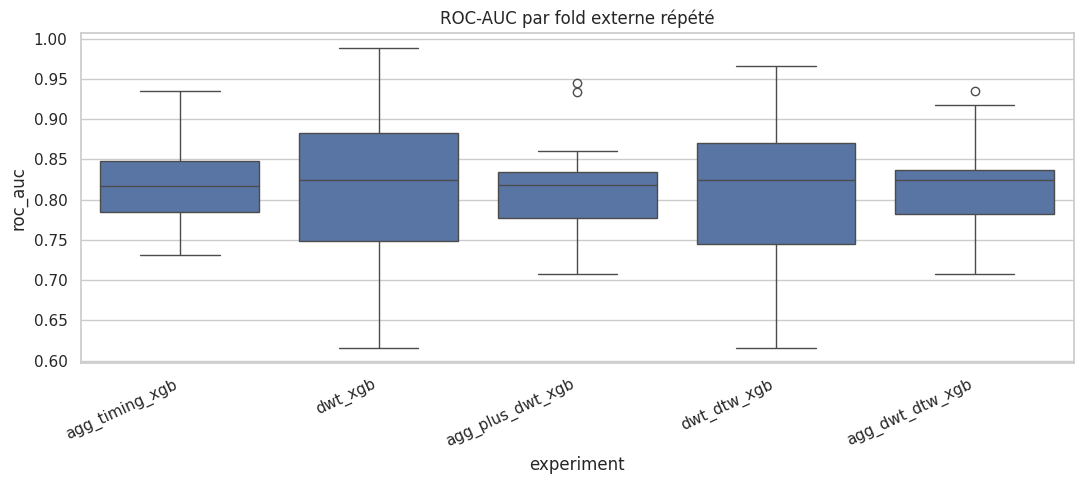

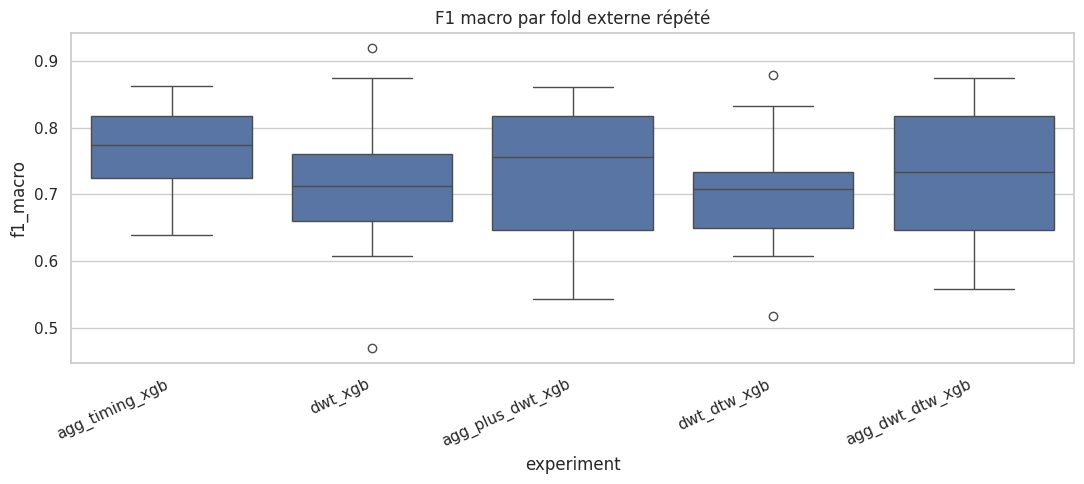

Baseline agg_timing_xgb:
roc_auc_mean     0.821
roc_auc_std       0.06
pr_auc_mean      0.879
f1_macro_mean    0.767
Name: 2, dtype: object

Best candidate:
experiment       agg_timing_xgb
roc_auc_mean              0.821
roc_auc_std                0.06
pr_auc_mean               0.879
f1_macro_mean             0.767
Name: 2, dtype: object

Export recommandé ? False


In [7]:
flat_summary = summary.copy()
flat_summary.columns = [f"{metric}_{stat}" for metric, stat in flat_summary.columns]
flat_summary = flat_summary.reset_index().sort_values("roc_auc_mean", ascending=False)
display(flat_summary)

plt.figure(figsize=(11, 5))
sns.boxplot(data=results_df, x="experiment", y="roc_auc")
plt.xticks(rotation=25, ha="right")
plt.title("ROC-AUC par fold externe répété")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.boxplot(data=results_df, x="experiment", y="f1_macro")
plt.xticks(rotation=25, ha="right")
plt.title("F1 macro par fold externe répété")
plt.tight_layout()
plt.show()

baseline = flat_summary.loc[flat_summary.experiment == "agg_timing_xgb"].iloc[0]
best = flat_summary.iloc[0]
print("Baseline agg_timing_xgb:")
print(baseline[["roc_auc_mean", "roc_auc_std", "pr_auc_mean", "f1_macro_mean"]])
print("\nBest candidate:")
print(best[["experiment", "roc_auc_mean", "roc_auc_std", "pr_auc_mean", "f1_macro_mean"]])

# Critère volontairement conservateur : amélioration moyenne >= 0.015 et variance non supérieure de plus de 0.02.
is_better = (
    best.experiment != "agg_timing_xgb"
    and best.roc_auc_mean >= baseline.roc_auc_mean + 0.015
    and best.roc_auc_std <= baseline.roc_auc_std + 0.020
)
print("\nExport recommandé ?", bool(is_better))


## 7. Rapport agrégé du meilleur candidat


In [8]:
best_name = flat_summary.iloc[0].experiment
best_oof = oof_df[oof_df.experiment == best_name].copy()
# Moyenne des prédictions lorsqu'une même session apparaît dans plusieurs répétitions.
best_session = best_oof.groupby("session_uid").agg(
    label=("label", "first"),
    pID=("pID", "first"),
    proba_mean=("proba_mean", "mean"),
).reset_index()
best_threshold, threshold_df = choose_threshold(best_session)
best_session["pred"] = (best_session.proba_mean >= best_threshold).astype(int)

print("best_name", best_name)
print("best_threshold", best_threshold)
display(threshold_df.sort_values(["balanced_accuracy", "f1_macro"], ascending=False).head(10).round(3))
print(classification_report(best_session.label, best_session.pred, target_names=["Contrôle", "Parkinson"]))
display(pd.DataFrame(confusion_matrix(best_session.label, best_session.pred), index=["Réel contrôle", "Réel Parkinson"], columns=["Prédit contrôle", "Prédit Parkinson"]))


best_name agg_timing_xgb
best_threshold 0.6200000000000001


,threshold,accuracy,balanced_accuracy,f1_macro,f1_binary,precision_binary,recall_binary,roc_auc,pr_auc
42,0.62,0.791,0.795,0.791,0.778,0.875,0.700,0.811,0.871
43,0.63,0.791,0.795,0.791,0.778,0.875,0.700,0.811,0.871
44,0.64,0.791,0.795,0.791,0.778,0.875,0.700,0.811,0.871
45,0.65,0.791,0.795,0.791,0.778,0.875,0.700,0.811,0.871
46,0.66,0.783,0.788,0.781,0.762,0.889,0.667,0.811,0.871
47,0.67,0.783,0.788,0.781,0.762,0.889,0.667,0.811,0.871
48,0.68,0.783,0.788,0.781,0.762,0.889,0.667,0.811,0.871
41,0.61,0.783,0.786,0.782,0.771,0.857,0.700,0.811,0.871
53,0.73,0.774,0.782,0.769,0.735,0.947,0.600,0.811,0.871
54,0.74,0.774,0.782,0.769,0.735,0.947,0.600,0.811,0.871


              precision    recall  f1-score   support

    Contrôle       0.73      0.89      0.80        55
   Parkinson       0.88      0.70      0.78        60

    accuracy                           0.79       115
   macro avg       0.80      0.80      0.79       115
weighted avg       0.81      0.79      0.79       115



,Prédit contrôle,Prédit Parkinson
Réel contrôle,49,6
Réel Parkinson,18,42


## 8. Export optionnel


In [9]:
if EXPORT_IF_BETTER and is_better:
    best_experiment = next(experiment for experiment in EXPERIMENTS if experiment["name"] == best_name)
    final_model = make_pipeline(best_experiment["features"], seed=RANDOM_STATE, use_dtw=best_experiment["use_dtw"])
    final_model.fit(segment_features[best_experiment["features"] + SIGNAL_COLS], segment_features.label.astype(int))
    artifact = {
        "pipeline": final_model,
        "features": best_experiment["features"],
        "model": "xgb",
        "experiment": best_name,
        "threshold": float(best_threshold),
        "min_segment_len": MIN_LEN,
        "window": WINDOW,
        "stride": STRIDE,
        "feature_builder": "not_app_integrated_dwt_dtw",
        "metrics_repeated_grouped_cv": flat_summary.to_dict(orient="records"),
        "note": "Experimental DWT/DTW + XGBoost model. Requires app integration before use in Flask predictor.",
    }
    joblib.dump(artifact, EXPORT_PATH)
    print("Exported", EXPORT_PATH)
else:
    print("No export. Either EXPORT_IF_BETTER=False or the candidate is not better under the conservative rule.")


No export. Either EXPORT_IF_BETTER=False or the candidate is not better under the conservative rule.


## 9. Analyse après exécution

Le résultat principal est net : **la dernière expérimentation ne justifie pas de remplacer `agg_timing_xgb`**.

La validation répétée (`3 x 5` folds groupés par sujet) donne :

| Variante | F1 macro | ROC-AUC | PR-AUC | Balanced accuracy |
|---|---:|---:|---:|---:|
| `agg_timing_xgb` | `0.767 ± 0.074` | `0.821 ± 0.060` | `0.879 ± 0.048` | `0.776 ± 0.071` |
| `agg_dwt_dtw_xgb` | `0.739 ± 0.099` | `0.820 ± 0.058` | `0.881 ± 0.045` | `0.752 ± 0.095` |
| `dwt_xgb` | `0.714 ± 0.111` | `0.820 ± 0.099` | `0.882 ± 0.065` | `0.728 ± 0.107` |
| `agg_plus_dwt_xgb` | `0.736 ± 0.096` | `0.819 ± 0.062` | `0.879 ± 0.048` | `0.749 ± 0.093` |
| `dwt_dtw_xgb` | `0.705 ± 0.094` | `0.816 ± 0.093` | `0.878 ± 0.062` | `0.719 ± 0.089` |

`agg_timing_xgb` reste le meilleur candidat en `ROC-AUC`, en `F1 macro`, en accuracy et en balanced accuracy. Les variantes DWT/DTW sont très proches en AUC, mais elles n’apportent pas de gain clair et dégradent généralement le F1 macro. Le meilleur concurrent, `agg_dwt_dtw_xgb`, fait presque jeu égal en AUC (`0.820` contre `0.821`) et en PR-AUC (`0.881` contre `0.879`), mais il est moins bon en F1 macro et plus instable sur les métriques de décision.

La règle conservatrice prévue dans le notebook demandait un gain d’au moins `0.015` de ROC-AUC moyenne sans hausse nette de variance. Elle n’est pas satisfaite. L’export est donc correctement refusé :

```text
Export recommandé ? False
No export. Either EXPORT_IF_BETTER=False or the candidate is not better under the conservative rule.
```

Le rapport agrégé du meilleur candidat confirme la baseline :

```text
best_name      : agg_timing_xgb
best_threshold : 0.62
```

Avec ce seuil agrégé, on obtient :

| Classe réelle | Prédit contrôle | Prédit Parkinson |
|---|---:|---:|
| Contrôle | 49 | 6 |
| Parkinson | 18 | 42 |

Le modèle privilégie une bonne précision Parkinson (`0.88`) mais manque encore une partie des cas Parkinson (`recall = 0.70`). Ce comportement est acceptable pour un prototype multimodal, car la modalité clavier ne doit pas être utilisée seule : elle fournit un score complémentaire qui sera fusionné avec la voix, le dessin ou d’autres tests.

Conclusion : **on garde `agg_timing_xgb` comme modèle clavier actuel**. Les features DWT/DTW sont intéressantes scientifiquement, mais sur ce dataset et avec cette validation stricte, elles ajoutent de la complexité sans gain suffisamment robuste. La prochaine amélioration pertinente ne serait pas d’ajouter encore des features clavier, mais plutôt :

- calibrer mieux le score (`CalibratedClassifierCV`, calibration Platt/isotonic dans un protocole groupé) ;
- ajuster le seuil selon l’objectif clinique simulé, par exemple plus de rappel si on veut minimiser les faux négatifs ;
- combiner réellement avec les autres modalités par fusion tardive.
